# Семинар 3. Методы работы с трекинговыми данными
Подготовил: Дурыгин Олег, Аркадий Аврамчук

Данные: трекинговые данные от Metrica Sports + StatsBomb

## 1. Installation and download data

In [ ]:
! pip install kloppy mplsoccer

## Блок 2. Загрузка данных Metrica Open Data
Данные матча загружаются через `kloppy.metrica.load_open_data` с параметрами `match_id=1`, `sample_rate=1/5`, `limit=100`, `coordinates="metrica"`.


In [ ]:
from kloppy.domain import Provider
from kloppy import metrica

dataset = metrica.load_open_data(
    match_id=1,
    # Optional arguments
    sample_rate=1 / 5,
    limit=100,
    coordinates="metrica",
)

dataset = dataset.transform(to_coordinate_system=Provider.STATSBOMB)
tracking_data = dataset.to_df()

In [ ]:
tracking_data.head()

,period_id,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y,ball_z,ball_speed,home_11_x,...,away_22_d,away_22_s,away_23_x,away_23_y,away_23_d,away_23_s,away_24_x,away_24_y,away_24_d,away_24_s
0,1,0 days 00:00:00.040000,1,None,None,54.803934,48.383142,None,None,0.093927,...,None,None,52.762459,75.576266,None,None,45.624578,56.784975,None,None
1,1,0 days 00:00:00.240000,6,None,None,66.514590,48.234778,None,None,0.160364,...,None,None,52.545574,75.680624,None,None,45.274819,56.569847,None,None
2,1,0 days 00:00:00.440000,11,None,None,67.463607,54.394836,None,None,0.097364,...,None,None,52.114098,76.188266,None,None,44.499267,56.259767,None,None
3,1,0 days 00:00:00.640000,16,None,None,68.411475,60.555636,None,None,0.074455,...,None,None,51.655082,76.683526,None,None,43.757931,55.934109,None,None
4,1,0 days 00:00:00.840000,21,None,None,68.316230,62.069815,None,None,0.075600,...,None,None,51.135246,77.081503,None,None,43.060948,55.681149,None,None


## Блок 3. Подготовка таблиц для анализа
Импортируются библиотеки, выполняется `dataset.to_df()`, приводятся имена колонок и формируются канонические таблицы `home_df`/`away_df` с координатами игроков и мяча.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch
from scipy.signal import savgol_filter

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.grid"] = True

tracking_df_kloppy = dataset.to_df().copy()

if isinstance(tracking_df_kloppy.columns, pd.MultiIndex):
    tracking_df_kloppy.columns = ["_".join([str(x) for x in col if str(x) not in {"", "None"}]) for col in tracking_df_kloppy.columns]
else:
    tracking_df_kloppy.columns = [str(c) for c in tracking_df_kloppy.columns]

tracking_df_kloppy.columns = [c.strip().replace(" ", "_").replace("-", "_").replace("/", "_") for c in tracking_df_kloppy.columns]

def axis_from_col(col_name):
    norm = col_name.lower().replace(":", "_").replace(".", "_")
    parts = [p for p in norm.split("_") if p]
    if not parts:
        return None
    return parts[-1] if parts[-1] in {"x", "y"} else None

def base_from_col(col_name):
    norm = col_name.replace(":", "_").replace(".", "_")
    parts = [p for p in norm.split("_") if p]
    if parts and parts[-1].lower() in {"x", "y"}:
        parts = parts[:-1]
    return "_".join(parts)

def team_from_base(base):
    low = base.lower()
    if "home" in low:
        return "Home"
    if "away" in low:
        return "Away"
    return None

def player_id_from_base(base):
    low = base.lower()
    for token in ["home", "away", "team", "player"]:
        low = low.replace(token, "_")
    low = "_".join([x for x in low.split("_") if x])
    safe = "".join([ch if ch.isalnum() else "_" for ch in low]).strip("_")
    return safe or "unknown"

def to_seconds(series):
    if pd.api.types.is_timedelta64_dtype(series):
        return series.dt.total_seconds()
    if pd.api.types.is_datetime64_any_dtype(series):
        return (series - series.iloc[0]).dt.total_seconds()
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().sum() > 0:
        return numeric
    return pd.Series(np.arange(len(series)) * 0.04)

time_candidates = [c for c in tracking_df_kloppy.columns if ("time" in c.lower() or "timestamp" in c.lower())]
if time_candidates:
    time_seconds = to_seconds(tracking_df_kloppy[time_candidates[0]])
else:
    time_seconds = pd.Series(np.arange(len(tracking_df_kloppy)) * 0.04)

home_df = pd.DataFrame({"Time [s]": time_seconds})
away_df = pd.DataFrame({"Time [s]": time_seconds})

ball_cols = {}
player_cols = {}

for col in tracking_df_kloppy.columns:
    axis = axis_from_col(col)
    if axis is None:
        continue

    low = col.lower()
    if "ball" in low:
        ball_cols[axis] = col
        continue

    base = base_from_col(col)
    team = team_from_base(base)
    if team is None:
        continue

    pid = player_id_from_base(base)
    key = (team, pid)
    if key not in player_cols:
        player_cols[key] = {}
    player_cols[key][axis] = col

for (team, pid), cols in sorted(player_cols.items()):
    if "x" not in cols or "y" not in cols:
        continue
    target_df = home_df if team == "Home" else away_df
    prefix = f"{team}_{pid}"
    target_df[f"{prefix}_x"] = pd.to_numeric(tracking_df_kloppy[cols["x"]], errors="coerce")
    target_df[f"{prefix}_y"] = pd.to_numeric(tracking_df_kloppy[cols["y"]], errors="coerce")

if "x" in ball_cols and "y" in ball_cols:
    bx = pd.to_numeric(tracking_df_kloppy[ball_cols["x"]], errors="coerce")
    by = pd.to_numeric(tracking_df_kloppy[ball_cols["y"]], errors="coerce")
    home_df["ball_x"] = bx
    home_df["ball_y"] = by
    away_df["ball_x"] = bx
    away_df["ball_y"] = by

print("Raw flattened dataframe shape:", tracking_df_kloppy.shape)
print("home_df shape:", home_df.shape)
print("away_df shape:", away_df.shape)


Raw flattened dataframe shape: (499, 97)
home_df shape: (499, 25)
away_df shape: (499, 25)


## Блок 4. Проверка структуры данных
Показываются первые названия колонок и выполняется проверка, что игроки обеих команд корректно распознаны после преобразования.


In [ ]:
print("Columns preview:")
print(list(tracking_df_kloppy.columns[:20]))

home_player_cols = [c for c in home_df.columns if c.endswith("_x") and c.startswith("Home_")]
away_player_cols = [c for c in away_df.columns if c.endswith("_x") and c.startswith("Away_")]

print("Detected Home players:", len(home_player_cols))
print("Detected Away players:", len(away_player_cols))

if len(home_player_cols) == 0 or len(away_player_cols) == 0:
    raise ValueError("Could not detect players from dataset.to_df(). Check flattened column names above.")


Columns preview:
['period_id', 'timestamp', 'frame_id', 'ball_state', 'ball_owning_team_id', 'ball_x', 'ball_y', 'ball_z', 'ball_speed', 'home_11_x', 'home_11_y', 'home_11_d', 'home_11_s', 'home_1_x', 'home_1_y', 'home_1_d', 'home_1_s', 'home_2_x', 'home_2_y', 'home_2_d']
Detected Home players: 11
Detected Away players: 11


## Блок 5. Служебные функции
Определяются функции для распознавания системы координат, перевода координат к метрам относительно центра поля и извлечения списков игроков/времени.


In [ ]:
def infer_coord_system(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    fx = x[np.isfinite(x)]
    fy = y[np.isfinite(y)]
    if len(fx) == 0 or len(fy) == 0:
        return "unknown"

    x_min, x_max = np.nanpercentile(fx, [1, 99])
    y_min, y_max = np.nanpercentile(fy, [1, 99])

    if -0.05 <= x_min and x_max <= 1.05 and -0.05 <= y_min and y_max <= 1.05:
        return "normalized_01"
    if -1.05 <= x_min and x_max <= 1.05 and -1.05 <= y_min and y_max <= 1.05:
        return "normalized_m11"
    if -55 <= x_min and x_max <= 55 and -37 <= y_min and y_max <= 37:
        return "centered_meters"
    if -5 <= x_min and x_max <= 110 and -5 <= y_min and y_max <= 73:
        return "pitch_meters"
    return "unknown"


def to_centered_meters(x, y, pitch_length=105.0, pitch_width=68.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    coord_system = infer_coord_system(x, y)

    if coord_system == "normalized_01":
        x_c = (x - 0.5) * pitch_length
        y_c = (0.5 - y) * pitch_width
    elif coord_system == "normalized_m11":
        x_c = x * (pitch_length / 2.0)
        y_c = -y * (pitch_width / 2.0)
    elif coord_system == "pitch_meters":
        x_c = x - pitch_length / 2.0
        y_c = y - pitch_width / 2.0
    else:
        x_c = x
        y_c = y
    return x_c, y_c


def centered_to_pitch_coords(x_centered, y_centered, pitch_length=105.0, pitch_width=68.0):
    x_plot = np.asarray(x_centered, dtype=float) + pitch_length / 2.0
    y_plot = np.asarray(y_centered, dtype=float) + pitch_width / 2.0
    return x_plot, y_plot


def get_player_prefixes(df, team_prefix="Home"):
    prefixes = sorted({
        c[:-2] for c in df.columns
        if c.startswith(f"{team_prefix}_") and c.endswith("_x") and "ball" not in c.lower()
    })
    return prefixes


def get_time_column(df):
    candidates = ["Time [s]", "Time", "time", "Timestamp", "timestamp"]
    for c in candidates:
        if c in df.columns:
            return c
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        raise ValueError("No time-like column found")
    return numeric_cols[0]


home_players = get_player_prefixes(home_df, "Home")
away_players = get_player_prefixes(away_df, "Away")
print(f"Detected Home players: {len(home_players)}")
print(f"Detected Away players: {len(away_players)}")
print("First Home players:", home_players[:5])
print("First Away players:", away_players[:5])


Detected Home players: 11
Detected Away players: 11
First Home players: ['Home_1', 'Home_10', 'Home_11', 'Home_2', 'Home_3']
First Away players: ['Away_15', 'Away_16', 'Away_17', 'Away_18', 'Away_19']


## Блок 5. Визуализация трекинга
Строится один кадр матча на поле `mplsoccer`: позиции игроков домашней и гостевой команды отображаются разными цветами.


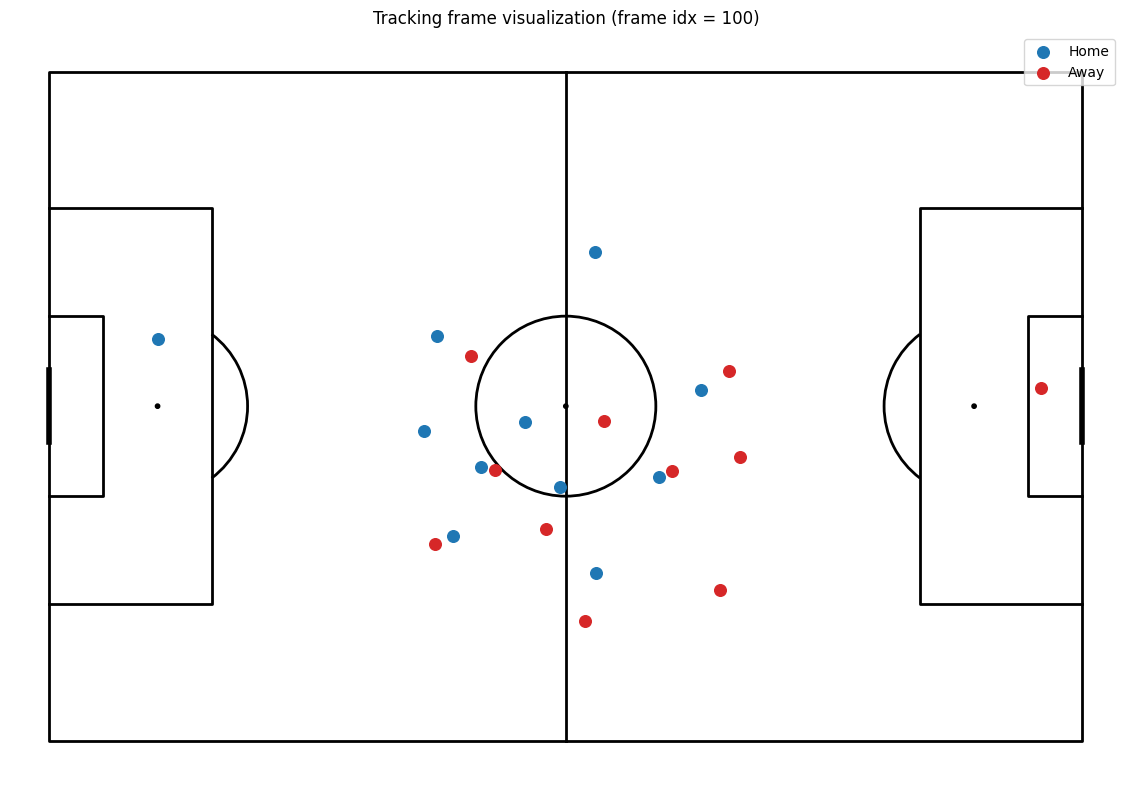

In [ ]:
# 1) Visualize one frame with mplsoccer
pitch = Pitch(pitch_type="custom", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(12, 8))

frame_idx = min(100, len(home_df) - 1, len(away_df) - 1)
hrow = home_df.iloc[frame_idx]
arow = away_df.iloc[frame_idx]

home_x, home_y = [], []
for p in home_players:
    x_col, y_col = f"{p}_x", f"{p}_y"
    if x_col in home_df.columns and y_col in home_df.columns:
        home_x.append(hrow[x_col])
        home_y.append(hrow[y_col])

away_x, away_y = [], []
for p in away_players:
    x_col, y_col = f"{p}_x", f"{p}_y"
    if x_col in away_df.columns and y_col in away_df.columns:
        away_x.append(arow[x_col])
        away_y.append(arow[y_col])

home_x_c, home_y_c = to_centered_meters(home_x, home_y)
away_x_c, away_y_c = to_centered_meters(away_x, away_y)

home_x_plot, home_y_plot = centered_to_pitch_coords(home_x_c, home_y_c)
away_x_plot, away_y_plot = centered_to_pitch_coords(away_x_c, away_y_c)

ax.scatter(home_x_plot, home_y_plot, c="tab:blue", s=70, label="Home")
ax.scatter(away_x_plot, away_y_plot, c="tab:red", s=70, label="Away")
ax.legend(loc="upper right")
ax.set_title(f"Tracking frame visualization (frame idx = {frame_idx})")
plt.show()


## Блок 6. Сравнение сглаживания траектории
Для одного игрока сравниваются исходная траектория, фильтр Савицкого-Голея и экспоненциальное скользящее среднее (EMA).


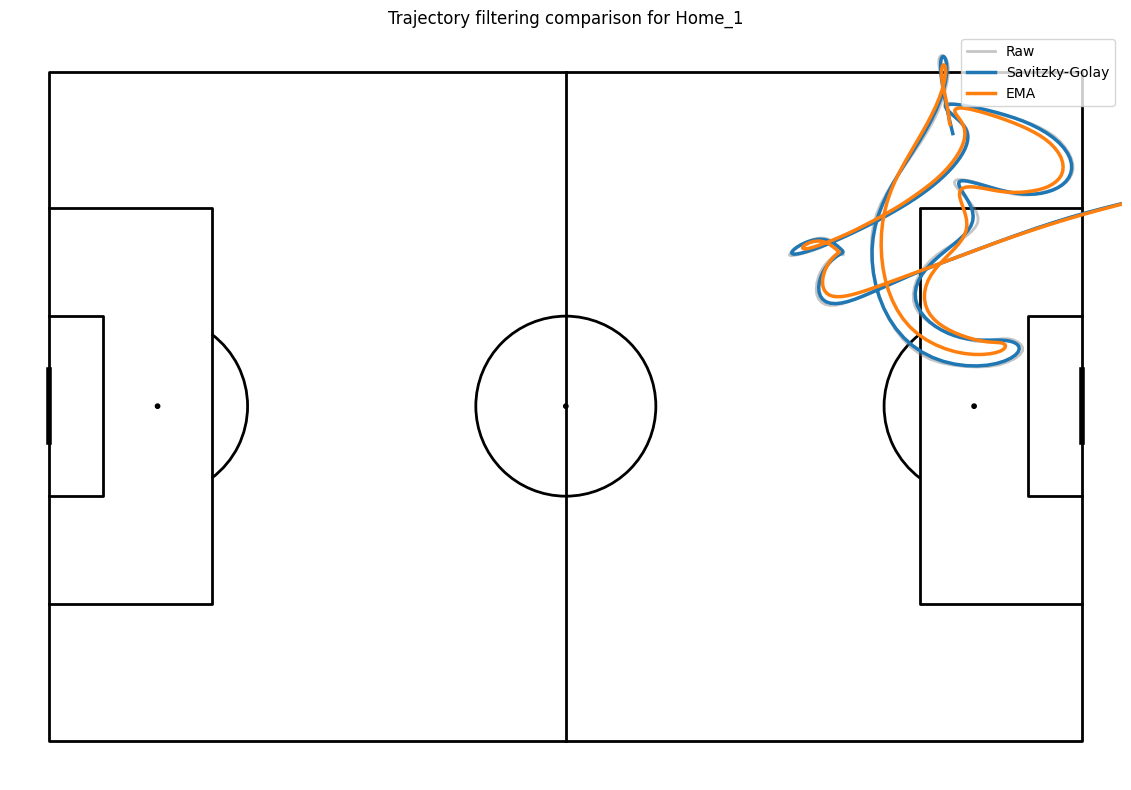

In [ ]:
# 2) Savitzky-Golay vs Exponential Moving Average for one player trajectory
player_id = home_players[0]
x_col = f"{player_id}_x"
y_col = f"{player_id}_y"

x_raw = pd.to_numeric(home_df[x_col], errors="coerce").values
y_raw = pd.to_numeric(home_df[y_col], errors="coerce").values

x_c, y_c = to_centered_meters(x_raw, y_raw)

x_interp = pd.Series(x_c).interpolate(limit_direction="both").values
y_interp = pd.Series(y_c).interpolate(limit_direction="both").values

n = len(x_interp)
window = min(21, n if n % 2 == 1 else n - 1)
if window < 5:
    window = 5 if n >= 5 else (n if n % 2 == 1 else n - 1)
if window <= 2:
    raise ValueError("Not enough points for Savitzky-Golay filtering")

x_sg = savgol_filter(x_interp, window_length=window, polyorder=2, mode="interp")
y_sg = savgol_filter(y_interp, window_length=window, polyorder=2, mode="interp")

x_ema = pd.Series(x_interp).ewm(span=10, adjust=False).mean().values
y_ema = pd.Series(y_interp).ewm(span=10, adjust=False).mean().values

pitch = Pitch(pitch_type="custom", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(12, 8))

xr_plot, yr_plot = centered_to_pitch_coords(x_interp, y_interp)
xs_plot, ys_plot = centered_to_pitch_coords(x_sg, y_sg)
xe_plot, ye_plot = centered_to_pitch_coords(x_ema, y_ema)

ax.plot(xr_plot, yr_plot, color="gray", alpha=0.45, lw=2, label="Raw")
ax.plot(xs_plot, ys_plot, color="tab:blue", lw=2.5, label="Savitzky-Golay")
ax.plot(xe_plot, ye_plot, color="tab:orange", lw=2.5, label="EMA")
ax.legend(loc="upper right")
ax.set_title(f"Trajectory filtering comparison for {player_id}")
plt.show()


## Блок 7. Фильтрация всех координат
Фильтр Савицкого-Голея применяется ко всем колонкам координат `*_x`/`*_y` для обеих команд.


In [ ]:
# 3) Apply Savitzky-Golay filter to all coordinate columns

def choose_window_length(series_len, requested=11, polyorder=2):
    w = min(requested, series_len if series_len % 2 == 1 else series_len - 1)
    if w <= polyorder:
        return None
    if w < 5 and series_len >= 5:
        w = 5
    if w % 2 == 0:
        w -= 1
    if w <= polyorder:
        return None
    return w


def apply_savgol_all_coordinates(df, window_length=11, polyorder=2):
    smoothed = df.copy()
    coord_cols = [c for c in df.columns if c.endswith("_x") or c.endswith("_y")]

    for c in coord_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().sum() < polyorder + 3:
            continue
        s_interp = s.interpolate(limit_direction="both")
        w = choose_window_length(len(s_interp), requested=window_length, polyorder=polyorder)
        if w is None:
            continue
        smoothed[c] = savgol_filter(s_interp.values, window_length=w, polyorder=polyorder, mode="interp")

    return smoothed


home_sg_df = apply_savgol_all_coordinates(home_df, window_length=11, polyorder=2)
away_sg_df = apply_savgol_all_coordinates(away_df, window_length=11, polyorder=2)

print("Savitzky-Golay filtering is applied to home and away tracking tables")
home_sg_df.head(2)


Savitzky-Golay filtering is applied to home and away tracking tables


,Time [s],Home_1_x,Home_1_y,Home_10_x,Home_10_y,Home_11_x,Home_11_y,Home_2_x,Home_2_y,Home_3_x,...,Home_6_x,Home_6_y,Home_7_x,Home_7_y,Home_8_x,Home_8_y,Home_9_x,Home_9_y,ball_x,ball_y
0,0.04,39.033256,28.433275,66.066768,44.821808,0.125603,41.312401,40.418785,40.666270,36.807351,...,50.643879,41.372346,47.316876,52.609410,54.795524,61.122603,63.052684,48.406123,59.230417,46.675068
1,0.24,38.998750,28.875718,66.077661,45.553901,0.114157,41.340096,40.315519,40.862313,37.025726,...,50.386837,41.822542,47.408703,53.303849,54.717155,61.869318,63.159541,49.315142,62.600683,51.303537


## Блок 8. Реализация Voronoi Diagram
Реализуются пример работы с данными StatsBomb


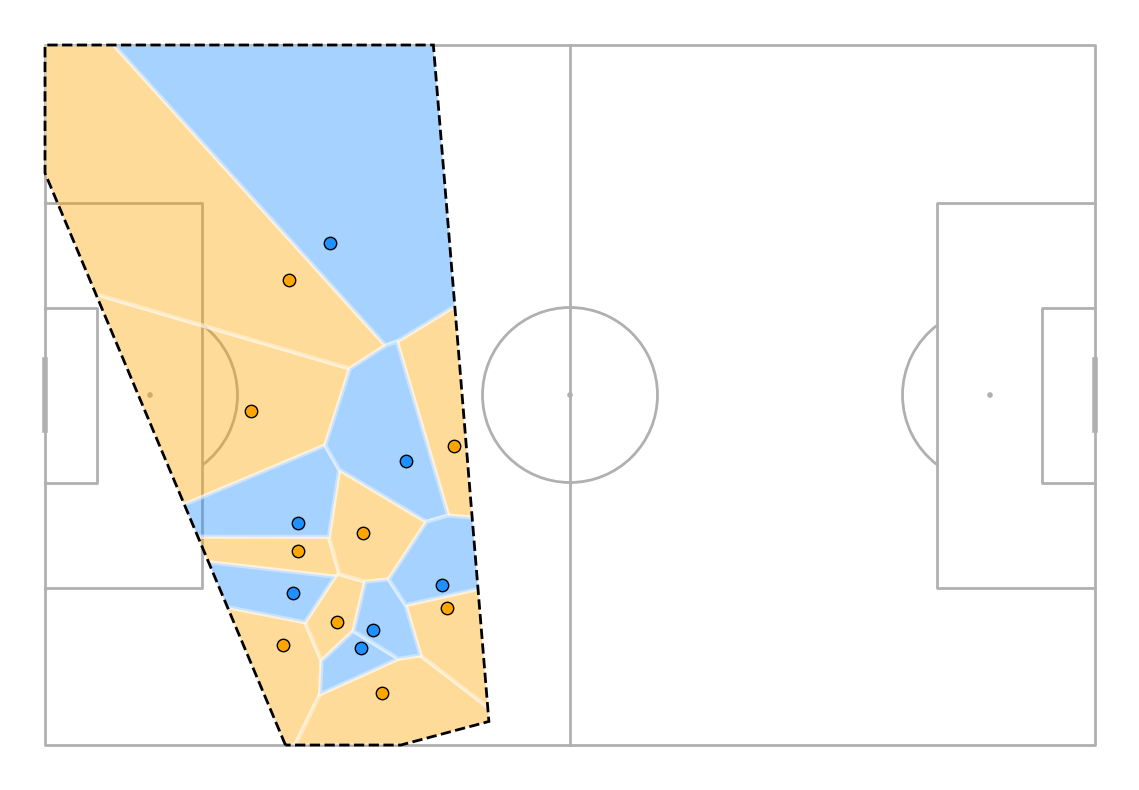

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen
import numpy as np

# get freeze frame data for game 3788741
parser = Sbopen()
frames, visible = parser.frame(3788741)

frame_idx = 50
frame_id = visible.iloc[50].id

visible_area = np.array(visible.iloc[frame_idx].visible_area).reshape(-1, 2)
player_position_data = frames[frames.id == frame_id]

teammate_locs = player_position_data[player_position_data.teammate]
opponent_locs = player_position_data[~player_position_data.teammate]

# draw plot
p = Pitch(pitch_type='statsbomb')
fig, ax = p.draw(figsize=(12,8))

# Plot Voronoi
team1, team2 = p.voronoi(player_position_data.x, player_position_data.y,
                         player_position_data.teammate)
t1 = p.polygon(team1, ax=ax, fc='orange', ec='white', lw=3, alpha=0.4)
t2 = p.polygon(team2, ax=ax, fc='dodgerblue', ec='white', lw=3, alpha=0.4)

# Plot players
sc1 = p.scatter(teammate_locs.x, teammate_locs.y, c='orange', s=80, ec='k', ax=ax)
sc2 = p.scatter(opponent_locs.x, opponent_locs.y, c='dodgerblue', s=80, ec='k', ax=ax)

# Plot the visible area
visible = p.polygon([visible_area], color='None', ec='k', linestyle='--', lw=2, ax=ax)

# clip each player to the visible area
for p1 in t1:
    p1.set_clip_path(visible[0])
for p2 in t2:
    p2.set_clip_path(visible[0])

plt.show()  # If you are using a Jupyter notebook you do not need this line